In [15]:
%pip install seaborn

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df=pd.read_csv('diabetes.csv')

In [18]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [21]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [22]:
df.shape

(768, 9)

In [23]:
print(df.duplicated().sum())

0


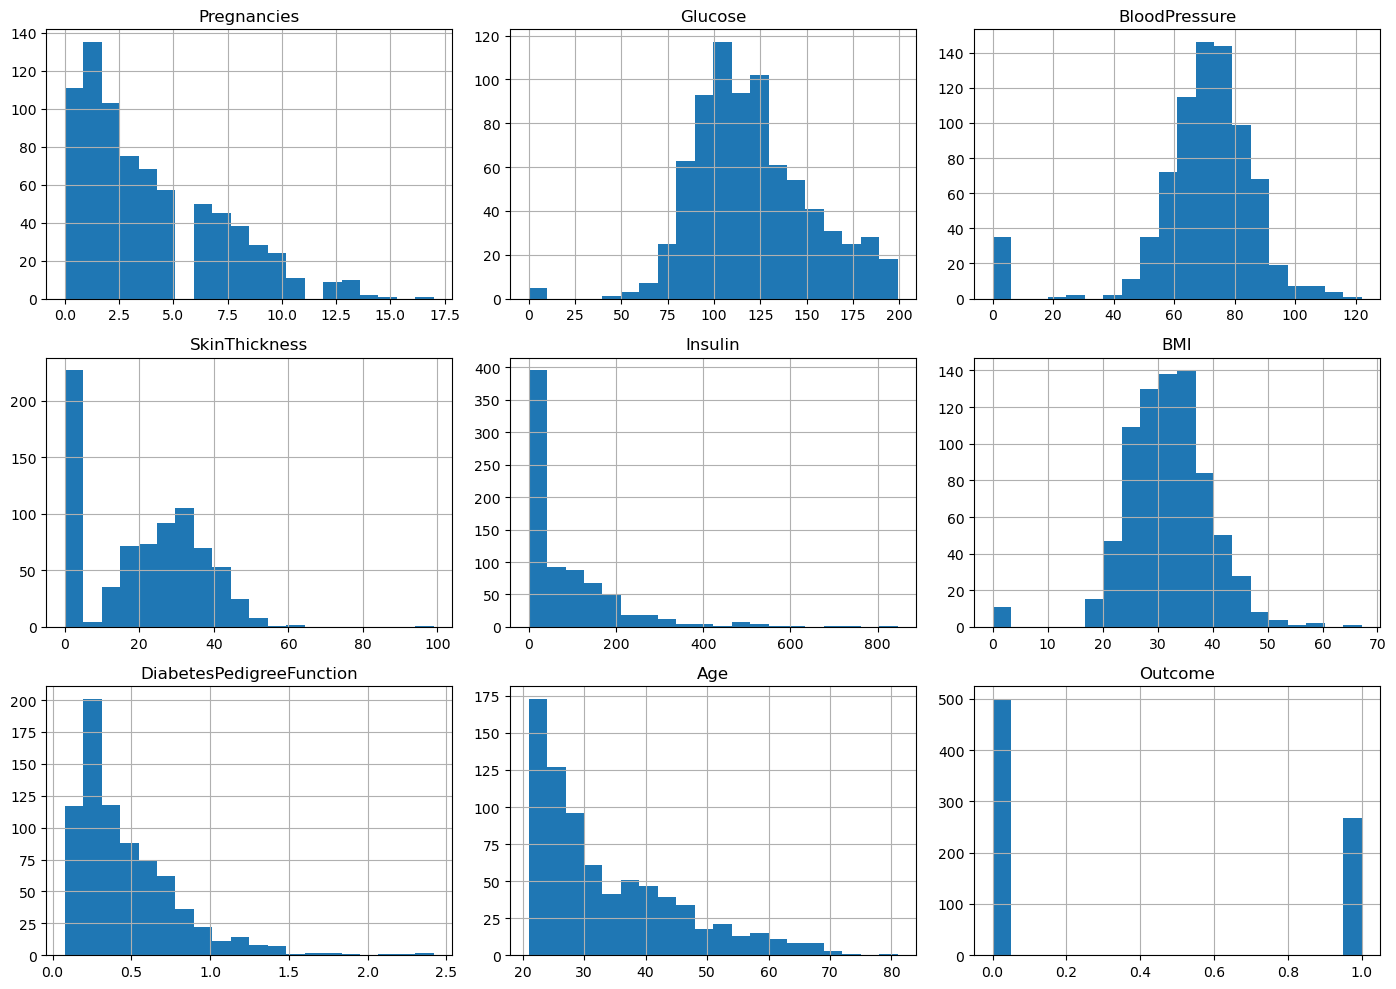

In [24]:
# Histogram

df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

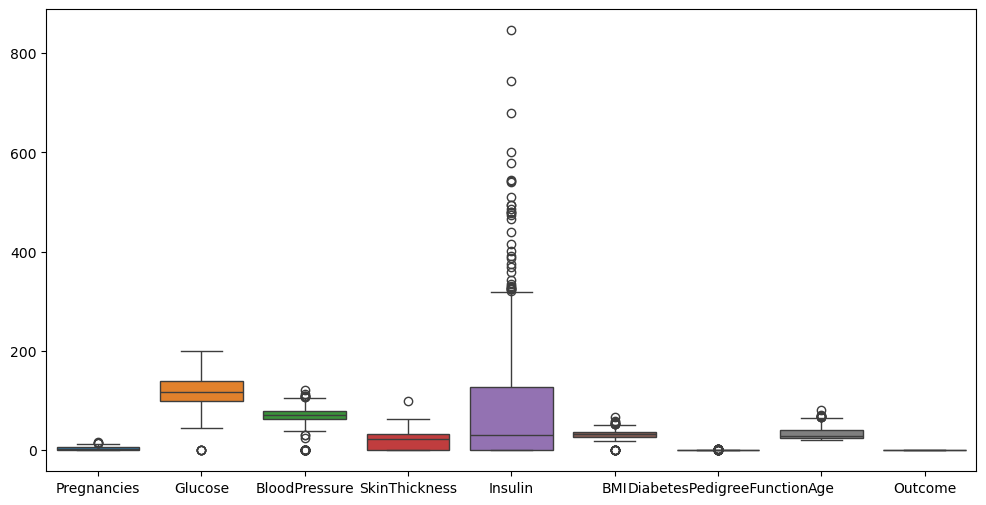

In [25]:
# BoxPlot

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()

In [26]:
for col in df:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    df[col]=df[col].clip(lower,upper)

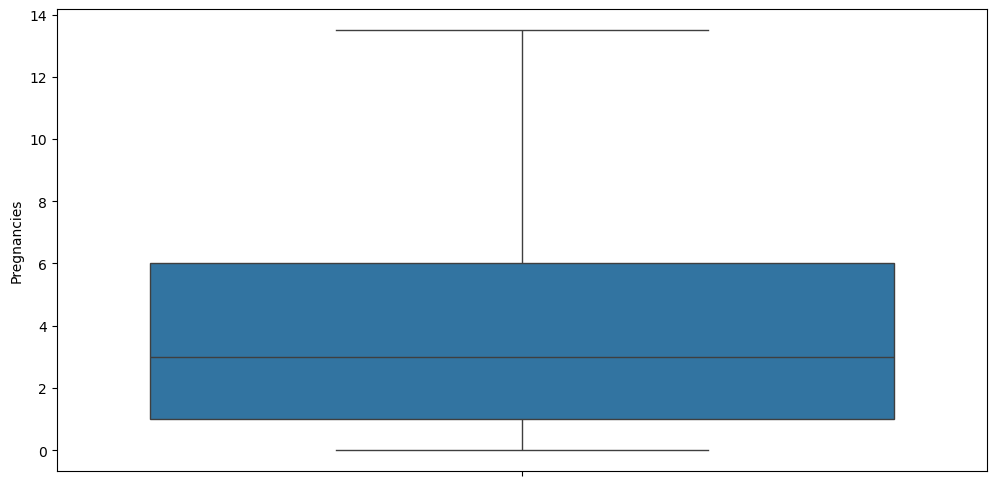

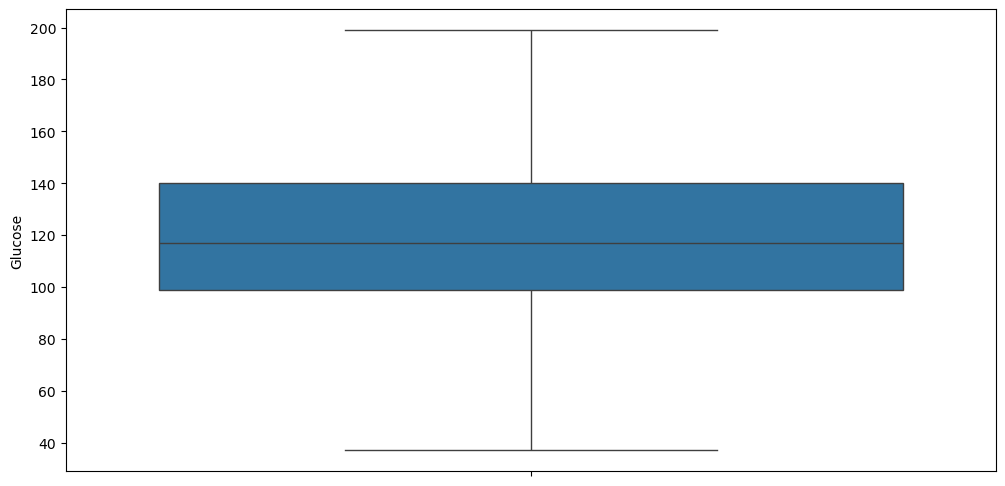

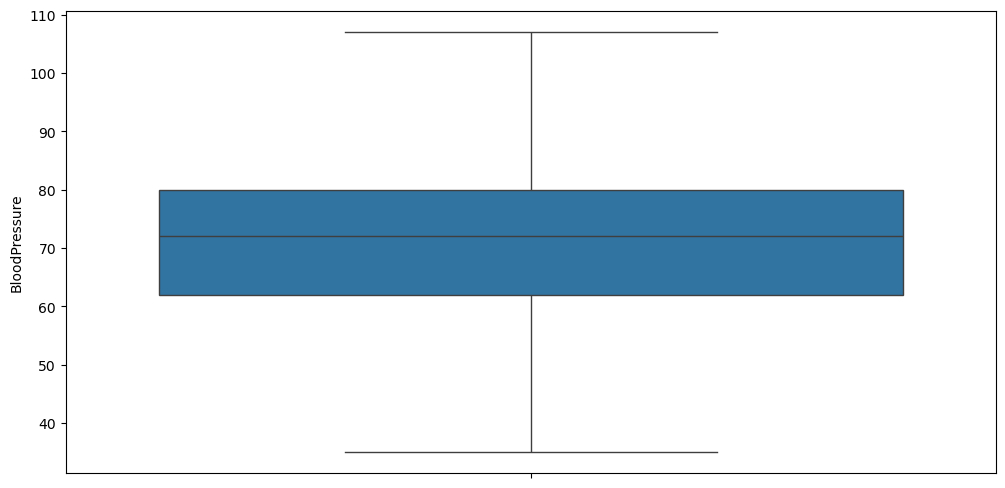

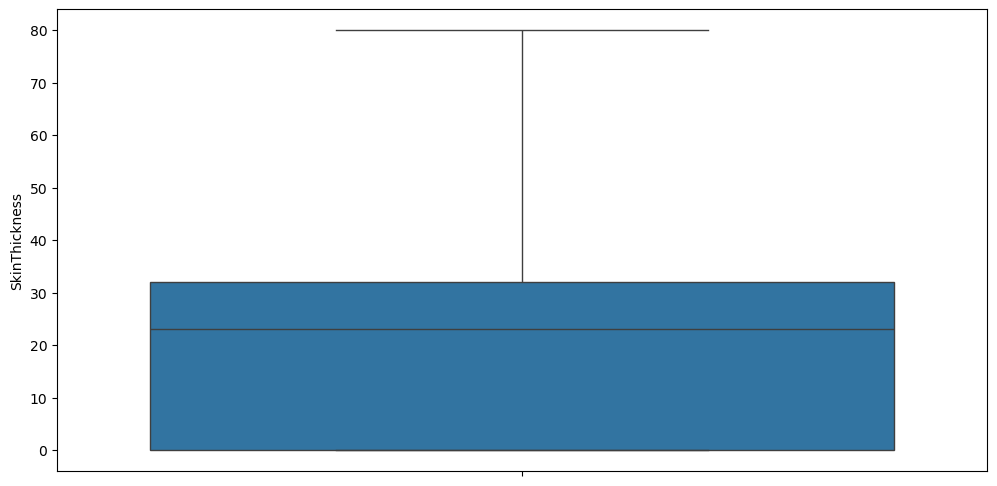

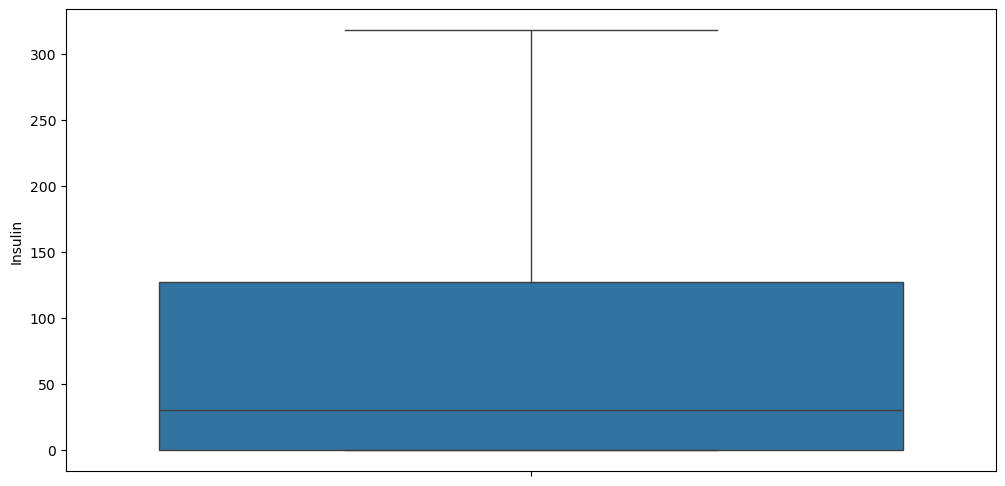

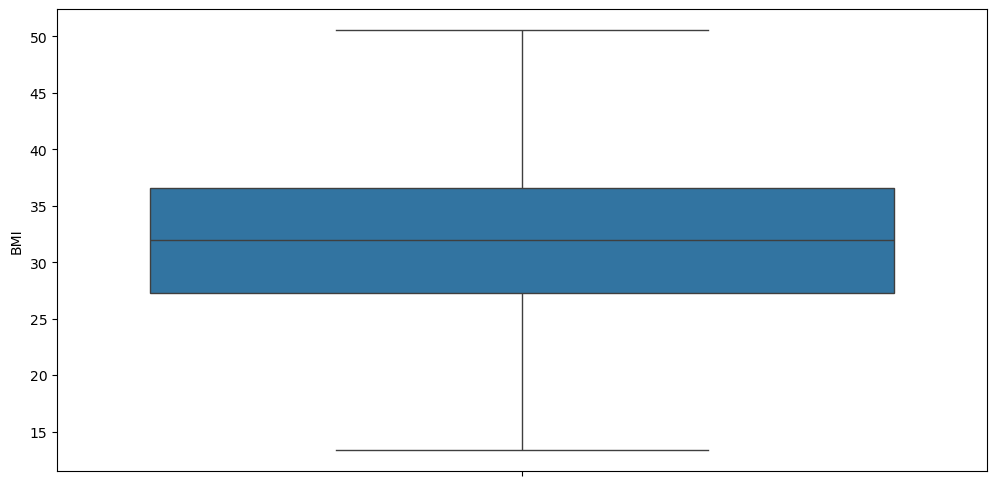

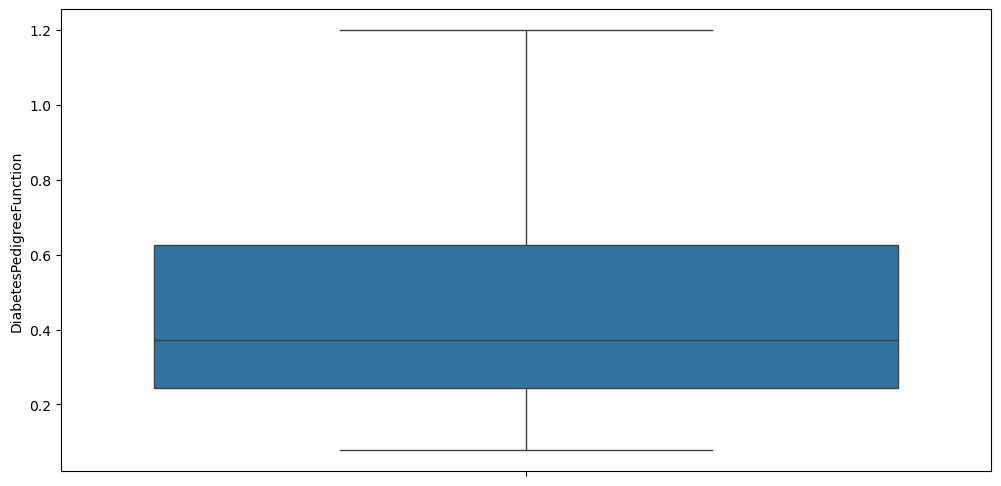

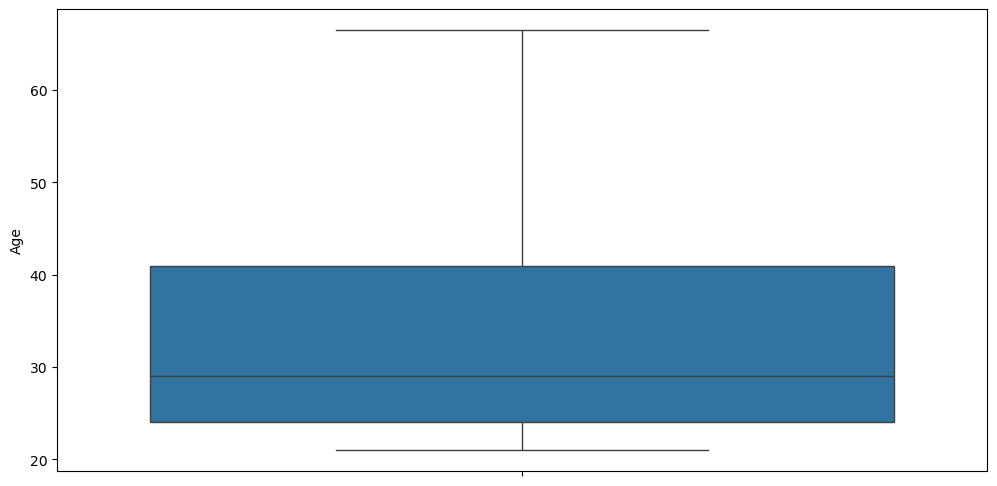

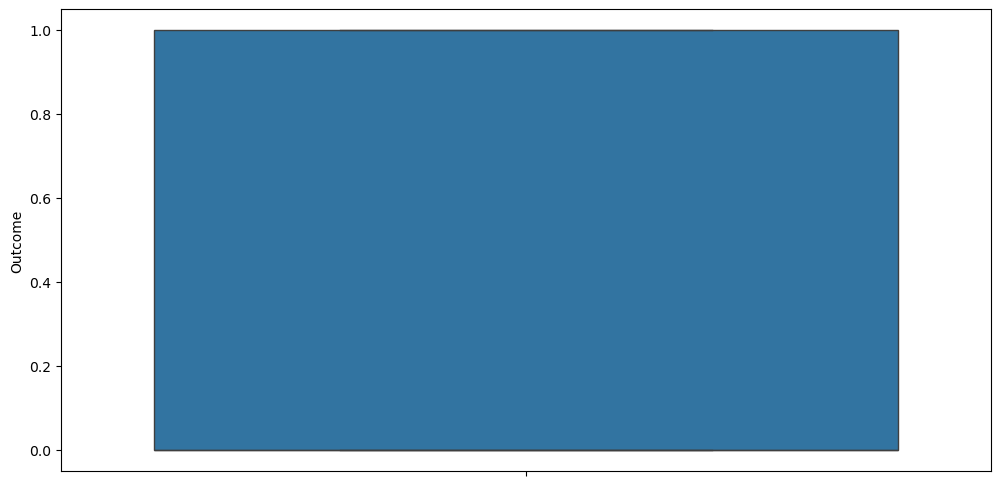

In [27]:
for col in df:
    plt.figure(figsize=(12,6))
    sns.boxplot(df[col])
    plt.show()

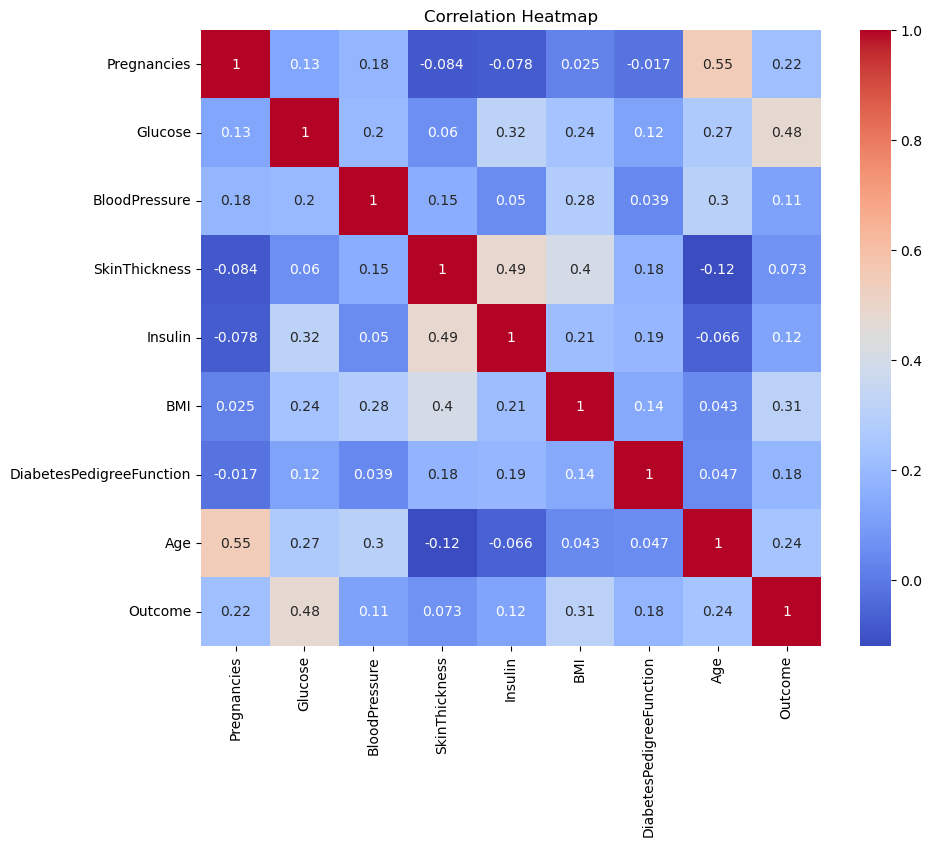

In [28]:
# Heat Map

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [29]:
# Missing Values

# Numerical columns
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [30]:
# Encoding

df = pd.get_dummies(df, drop_first=True, dtype=int)

In [31]:
x = df.drop('Outcome',axis=1)
y=df['Outcome']

In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
print('Training data : ',x_train.shape)
print('Testing data : ',x_test.shape)

Training data :  (614, 8)
Testing data :  (154, 8)


In [33]:
from sklearn.preprocessing import StandardScaler
SS=StandardScaler()
SS_X=SS.fit_transform(x_train)
S=SS.transform(x_test)

In [34]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(SS_X,y_train)
y_pred=model.predict(S)
y_prob=model.predict_proba(S)[:,1]

In [35]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
Accuracy=accuracy_score(y_test,y_pred)
print('Accuracy : ',round(Accuracy,2))
Precision=precision_score(y_test,y_pred)
print('Precision : ',round(Precision,2))
Recall =recall_score(y_test,y_pred)
print('Recall : ',round(Recall,2))
F1_score=f1_score(y_test,y_pred)
print('F1-Score : ',round(F1_score,2))
Roc_Auc=roc_auc_score(y_test,y_prob)
print('Roc_Auc : ',round(Roc_Auc,2))

Accuracy :  0.75
Precision :  0.65
Recall :  0.65
F1-Score :  0.65
Roc_Auc :  0.81


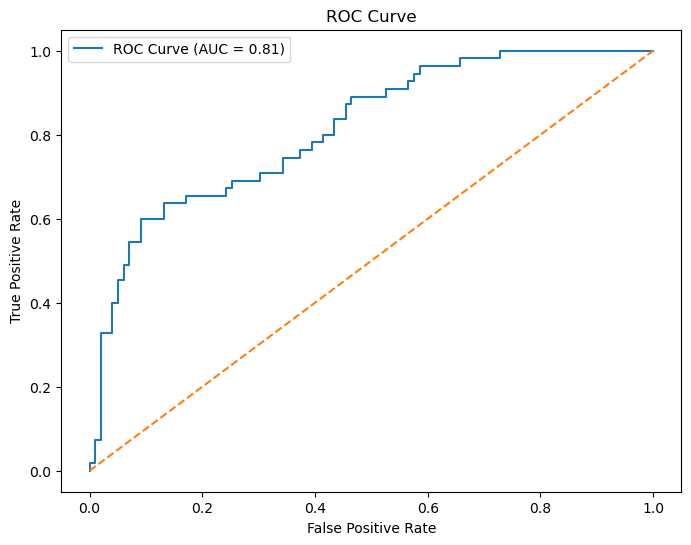

In [36]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test,y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr,tpr,label=f"ROC Curve (AUC = {Roc_Auc:.2f})")
plt.plot([0, 1],[0, 1],linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [37]:
coefficients = pd.DataFrame({'Feature': x.columns,'Coefficient': model.coef_[0]})
coefficients = coefficients.sort_values(by='Coefficient',ascending=False)
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])
print(round(coefficients,2))

                    Feature  Coefficient  Odds_Ratio
1                   Glucose         1.08        2.96
5                       BMI         0.77        2.17
7                       Age         0.44        1.55
6  DiabetesPedigreeFunction         0.28        1.32
0               Pregnancies         0.20        1.22
3             SkinThickness         0.04        1.04
4                   Insulin        -0.22        0.81
2             BloodPressure        -0.24        0.78


In [38]:
import joblib

In [39]:
joblib.dump(model,"logistic_model.pkl")
joblib.dump(SS,"scaler.pkl")
joblib.dump(x.columns.tolist(),"feature_names.pkl")
print("\nModel saved successfully!")


Model saved successfully!
